In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [25]:
data1 = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Regression.csv"
df = pd.read_csv(data1)
print(df.dtypes)

month_number           int64
year_val               int64
listing_tier          object
brand                 object
analytic_category     object
total_gmv            float64
avg_unit_price       float64
total_orders           int64
avg_delivery_days    float64
dtype: object


R2: 0.66
MAE: 9042921489.08


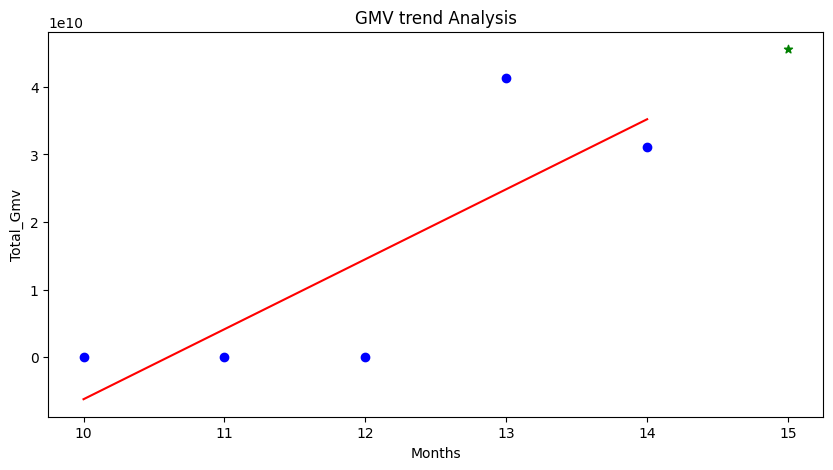

In [27]:
df['time_index'] = (df['year_val'] - df['year_val'].min()) * 12 + df['month_number']
trend_df = df.groupby('time_index')['total_gmv'].sum().reset_index()

X= trend_df[['time_index']]
y= trend_df['total_gmv']
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

next_month_index = np.array([[trend_df['time_index'].max() +1 ]])
future_prediction = model.predict(next_month_index)

print(f"R2: {r2:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(10,5))
plt.scatter(X, y, color ='blue', label='Actual_Sales')
plt.plot(X, y_pred, color ='red', label = 'Trend_line')
plt.scatter(next_month_index, future_prediction, color='green' ,marker ='*', label = "Next Month Forecast")
plt.title('GMV trend Analysis')
plt.xlabel('Months')
plt.ylabel('Total_Gmv')
plt.show()
          

   time_index
0          10
1          11
2          12
3          13
4          14
